In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [37]:
df = pd.read_csv('student_data.csv')
df.head(5)

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [38]:
df.dtypes

school        object
sex           object
age            int64
address       object
famsize       object
Pstatus       object
Medu           int64
Fedu           int64
Mjob          object
Fjob          object
reason        object
guardian      object
traveltime     int64
studytime      int64
failures       int64
schoolsup     object
famsup        object
paid          object
activities    object
nursery       object
higher        object
internet      object
romantic      object
famrel         int64
freetime       int64
goout          int64
Dalc           int64
Walc           int64
health         int64
absences       int64
G1             int64
G2             int64
G3             int64
dtype: object

- The dataset contains both numerical and categorical features.
 No data type conversion is required.

## Missing Values:


 

In [39]:
df.isnull().sum()

school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

- The dataset does not contain any missing values.

In [40]:
# Create Missing Values
df_missing = df.copy()
df_missing.loc[0:5, 'age'] = np.nan
df_missing.isnull().sum()

school        0
sex           0
age           6
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

In [41]:
# Handle Missing Values using Mean imputation
df_imputed_mean = df_missing.copy()
df_imputed_mean['age'].fillna(df_imputed_mean['age'].mean(), inplace=True)
df_imputed_mean.head(10)

<ipython-input-41-72c398ed5a58>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed_mean['age'].fillna(df_imputed_mean['age'].mean(), inplace=True)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,16.70437,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,16.70437,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,16.70437,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,16.70437,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16.70437,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10
5,GP,M,16.70437,U,LE3,T,4,3,services,other,...,5,4,2,1,2,5,10,15,15,15
6,GP,M,16.00000,U,LE3,T,2,2,other,other,...,4,4,4,1,1,3,0,12,12,11
7,GP,F,17.00000,U,GT3,A,4,4,other,teacher,...,4,1,4,1,1,1,6,6,5,6
8,GP,M,15.00000,U,LE3,A,3,2,services,other,...,4,2,2,1,1,1,0,16,18,19
9,GP,M,15.00000,U,GT3,T,3,4,other,other,...,5,5,1,1,1,5,0,14,15,15




- I used mean imputation to handle missing values in the 'age' column because  it does not contain extreme outliers.
Mean imputation was chosen because it preserves the dataset size and avoids losing data. It is also suitable for numerical data 

# Detect outliers using IQR:


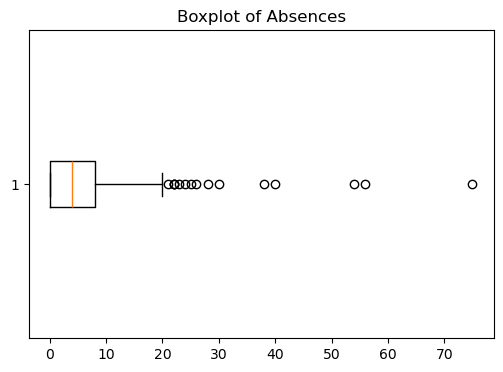

In [42]:
plt.figure(figsize=(6,4))
plt.boxplot(df['absences'], vert=False)

plt.title('Boxplot of Absences')
plt.show()

- The boxplot shows multiple outliers in the 'absences' column, indicating extreme values in the data.

In [43]:
Q1 = df['absences'].quantile(0.25)
Q3 = df['absences'].quantile(0.75)

IQR = Q3 - Q1
lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

outliers = df[(df['absences'] < lower) | (df['absences'] > upper)]
outliers.head()

,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
40,GP,F,16,U,LE3,T,2,2,other,other,...,3,3,3,1,2,3,25,7,10,11
74,GP,F,16,U,GT3,T,3,3,other,services,...,4,3,3,2,4,5,54,11,12,11
103,GP,F,15,U,GT3,T,3,2,services,other,...,4,3,5,1,1,2,26,7,6,6
183,GP,F,17,U,LE3,T,3,3,other,other,...,5,3,3,2,3,1,56,9,9,8
198,GP,F,17,U,GT3,T,4,4,services,teacher,...,4,2,4,2,3,2,24,18,18,18


In [44]:
# Remove Outliers using IQR
df_no_outliers = df[(df['absences'] >= lower) & (df['absences'] <= upper)]
print("Original shape : " , df.shape)
print("After removing outliers : " , df_no_outliers.shape)

Original shape :  (395, 33)
After removing outliers :  (380, 33)


In [45]:
# Cap Outliers using Percentiles

lower_cap = df['absences'].quantile(0.05)
upper_cap = df['absences'].quantile(0.95)
df_capped = df.copy()
df_capped['absences'] = df_capped['absences'].clip(lower_cap, upper_cap)

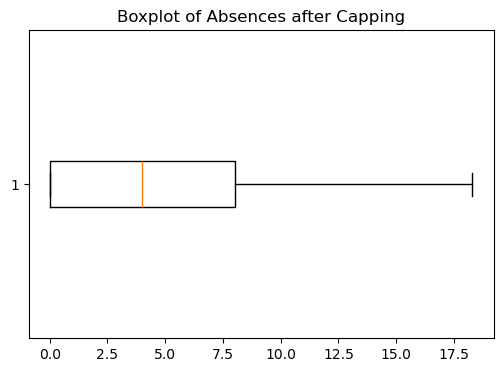

In [46]:

plt.figure(figsize=(6,4))
plt.boxplot(df_capped['absences'], vert=False)

plt.title('Boxplot of Absences after Capping')
plt.show()

- Outliers were handled using capping 
This method is an alternative to removing outliers, as it preserves the dataset by limiting extreme values instead of deleting them.


# Min-Max Normalization:

In [47]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df_scaled = df[['absences','age']].copy()
df_scaled[['absences','age']] = scaler.fit_transform(df_scaled)
df_scaled.head()

,absences,age
0,0.080000,0.428571
1,0.053333,0.285714
2,0.133333,0.000000
3,0.026667,0.000000
4,0.053333,0.142857



- Min-Max normalization was applied using  to scale the numerical features ('absences' and 'age') between 0 and 1.

# Z-score Normalization :

In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
df_zscore = df[['absences', 'age']].copy()
df_zscore[['absences', 'age']] = scaler.fit_transform(df_zscore)
df_zscore.head()

,absences,age
0,0.036424,1.023046
1,-0.213796,0.238380
2,0.536865,-1.330954
3,-0.464016,-1.330954
4,-0.213796,-0.546287


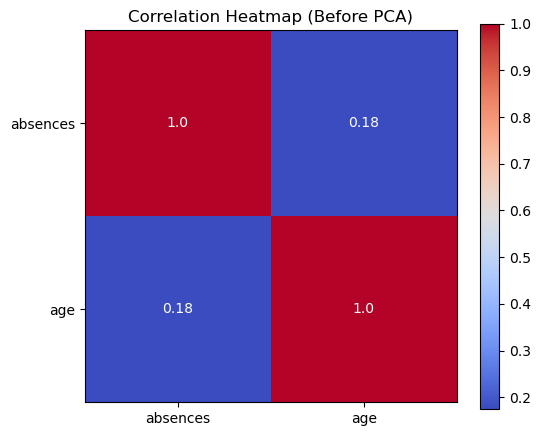

In [49]:
corr = df[['absences', 'age']].corr()
plt.figure(figsize=(6,5))
img = plt.imshow(corr, cmap='coolwarm')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(j, i, round(corr.iloc[i, j], 2),
                 ha='center', va='center', color='white')

plt.title('Correlation Heatmap (Before PCA)')
plt.show()


- The correlation value is approximately 0.18, which indicates a weak relationship between the two features.
This means that there is no strong linear relationship between them.

- Since the correlation between the features is weak, PCA is not necessary in this case.
However, PCA will still be applied for demonstration purposes.

 # Data Reduction – Principal Component Analysis (PCA) : 

In [50]:
from sklearn.decomposition import PCA
X = df[['absences', 'age']]
pca = PCA(n_components=2)
principal_components = pca.fit_transform(X)
print("Explained Variance Ratio:", pca.explained_variance_ratio_)

Explained Variance Ratio: [0.97598846 0.02401154]


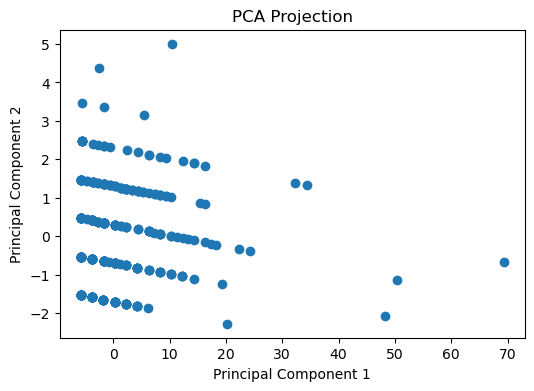

In [51]:

plt.figure(figsize=(6,4))
plt.scatter(principal_components[:,0], principal_components[:,1])

plt.title("PCA Projection")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()


- This plot shows the data after applying PCA.
The shape looks different because the data (age and absences) has simple and repeated values, so the points appear in lines.
This is normal and does not mean there is an error.